In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv
/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/LCDataDictionary.xlsx


# Capstone 2: Probability of Default (PD) Model

## 1. Project Overview
This project aims to build a predictive model to estimate the probability of loan delinquency using LendingClub data.

## 2. Data Loading and Initial Exploration

We begin by loading the LendingClub dataset from Kaggle and performing an initial exploration of its structure.

To ensure efficiency and avoid memory issues, a subset of 10,000 rows is first used for preliminary inspection. This allows us to review the dataset’s structure, examine column names, and identify potential data quality issues before working with the full dataset.

After gaining an initial understanding, the full dataset is loaded to conduct a complete analysis. This step ensures that all observations are included for accurate modeling of loan default behavior.

We also verify the dataset directory to confirm the presence of the main dataset file and accompanying data dictionary.

In [2]:
#Checking the dataset directory
os.listdir('/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv')

['loan.csv', 'LCDataDictionary.xlsx']

In [3]:
# Looking at the first 5 rows of the piece of our dataset
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv',
    nrows = 10000,
    low_memory = False
)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Checking the shape, which tells us that it contains 145 columns
df.shape

(10000, 145)

In [5]:
#Checking all the columns
pd.set_option('display.max_columns', None)
list(df.columns)

['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 'dti_joint',
 'verification_status_joint',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_

In [6]:
df['loan_status'].value_counts()

loan_status
Current               9800
Fully Paid             177
In Grace Period         11
Late (31-120 days)      10
Charged Off              1
Late (16-30 days)        1
Name: count, dtype: int64

This piece of dataset (10,000 rows) is heavily imbalanced with only 1 "Charged Off" loan. "Current" loans cannot be used for PD model, because we don't know if they will default yet. We are going to examine full dataset next and 
create a binary model.


In [7]:
# Loading a full dataset
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/adarshsng/lending-club-loan-data-csv/loan.csv',
    low_memory = False
)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.0,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.0,Apr-2001,1.0,NaN,45.0,9.0,1.0,4341,10.3,34.0,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.0,0.0,0.0,Feb-2019,84.92,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,0.0,16901.0,2.0,2.0,1.0,2.0,2.0,12560.0,69.0,2.0,7.0,2137.0,28.0,42000.0,1.0,11.0,2.0,9.0,1878.0,34360.0,5.9,0.0,0.0,140.0,212.0,1.0,1.0,0.0,1.0,NaN,2.0,NaN,0.0,2.0,5.0,3.0,3.0,16.0,7.0,18.0,5.0,9.0,0.0,0.0,0.0,3.0,100.0,0.0,1.0,0.0,60124.0,16901.0,36500.0,18124.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.0,Jun-1987,0.0,71.0,75.0,13.0,1.0,12315,24.2,44.0,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.0,0.0,0.0,Feb-2019,777.23,Mar-2019,Feb-2019,0.0,NaN,1,Individual,NaN,NaN,NaN,0.0,1208.0,321915.0,4.0,4.0,2.0,3.0,3.0,87153.0,88.0,4.0,5.0,998.0,57.0,50800.0,2.0,15.0,2.0,10.0,24763.0,13761.0,8.3,0.0,0.0,163.0,378.0,4.0,3.0,3.0,4.0,NaN,4.0,NaN,0.0,2.0,4.0,4.0,9.0,27.0,8.0,14.0,4.0,13.0,0.0,0.0,0.0,6.0,95.0,0.0,1.0,0.0,372872.0,99468.0,15000.0,94072.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt cons

In [8]:
df.shape

(2260668, 145)

In our full dataset we have 2.26 million rows and 145 columns.


In [9]:
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

## 3. Initial Data Cleaning and Dataset Refinement
This section focuses on preparing and refining the dataset prior to exploratory analysis and predictive modeling. The process includes defining the target variable, removing potential data leakage features, examining missing values, reviewing data types, and transforming variables into formats suitable for analysis. Additional feature refinement steps are performed to reduce noise, improve data quality, and ensure that the remaining variables reflect information available at the time of loan origination

## 3.1 Target Variable Creation and Distribution

The `loan_status` variable represents the current or final repayment state of each loan and serves as the foundation for defining the target variable in this analysis. Since the objective is to model the probability of delinquency (PD), only loans with known and reliable outcomes were considered. Loans labeled as **“Current”** were excluded because their final repayment status has not yet been determined, and including them would introduce uncertainty and potential misclassification into the model. Similarly, intermediate statuses such as **“In Grace Period”** and early-stage delinquency (e.g., **“Late (16–30 days)”**) were removed, as these loans may still recover and do not necessarily represent true delinquency events.

To construct a binary target variable, loans were categorized into two groups based on their repayment outcomes. Loans labeled as **“Fully Paid”** were classified as non-default (0), indicating successful repayment. Loans labeled as **“Charged Off”**, **“Default”**, and **“Late (31–120 days)”** were classified as `bad_status`(1), as these represent severe delinquency or failure to meet repayment obligations. A new variable, was created to capture this classification, where 0 indicates a non-delinquent loan, named `good_status`, and 1 indicates a high-risk loan. This transformation ensures a clear and consistent definition of delinquency, which is essential for building a reliable predictive model.
The following steps implement this classification by filtering relevant loan statuses and creating a binary target variable.

In [10]:
# Defining categories

bad_status = [
    'Charged Off', 
    'Default', 
    'Late (31-120 days)'
]

good_status = ['Fully Paid']

In [11]:
# Filter dataset

df = df[df['loan_status'].isin(bad_status + good_status)].copy()

In [12]:
# Creating a binary target

df['bad_status'] = df['loan_status'].apply(lambda x:1 if x in bad_status else 0)

In [13]:
# Check the result
df['bad_status'].value_counts()

bad_status
0    1041952
1     283583
Name: count, dtype: int64



After defining the binary target variable `bad_status`, the distribution of loan outcomes was examined using the *value_counts()* method, which counts the number of occurrences of each unique value in the column. The results show that the majority of loans are classified as non-delinquent (0), with 1,041,952 observations, while 283,583 loans are classified as high-risk (1).

This indicates that the dataset is moderately imbalanced, with approximately 79% non-delinquent cases and 21% delinquent cases. Such an imbalance is typical in credit risk datasets, as most borrowers successfully meet their repayment obligations, while a smaller proportion experience financial distress.

This class imbalance is an important consideration for modeling, as predictive algorithms must be able to accurately identify the minority class (default cases) despite their lower frequency.



## 3.2 Removal of Data Leakage Features and Target Variable 


Certain variables were removed from the dataset due to potential data leakage, as they contain information that becomes available only after the loan has been issued or after repayment behavior has already occurred. Including such variables would result in unrealistic model performance, since they effectively reveal the outcome of the loan.

Examples of these variables include total payment amounts, recovery-related metrics, and last payment information, all of which are directly influenced by whether a borrower ultimately defaults. To ensure that the model reflects a real-world prediction scenario at the time of loan origination, these columns were excluded from the analysis.

The following variables were identified as containing post-outcome or repayment-related information and were therefore removed: total payment variables (total_pymnt, total_pymnt_inv), recovery-related variables (recoveries, collection_recovery_fee), repayment components (total_rec_prncp, total_rec_int, total_rec_late_fee), and variables reflecting repayment timing and remaining balance (last_pymnt_d, last_pymnt_amnt, out_prncp, out_prncp_inv).

In [14]:
# Creating leakage list:

leakage_cols = [
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'out_prncp',
    'out_prncp_inv'
]

In [15]:
# Dropping the leakage columns from our dataset:

df = df.drop(columns = leakage_cols, errors = 'ignore')

In [16]:
# Checking the new shape of the dataset:
df.shape

(1325535, 135)

In [17]:
# Checking if all of the leakage columns got dropped
[col for col in leakage_cols if col in df.columns]

[]

After filtering the dataset and removing leakage variables, the number of columns decreased from 145 to 135. Although 11 leakage columns were removed, one new binary target column, default, was added, resulting in a net reduction of 10 columns.

**Removal of Target Variable Source**

After constructing the binary target variable `bad_status`, the original `loan_status` column has to be removed from the dataset. This is because `loan_status` directly reflects the final outcome of each loan and was used to derive the target variable. Keeping this column in the dataset would introduce target leakage, allowing the model to trivially infer the outcome and resulting in misleading performance. Therefore, it was excluded to ensure that the model relies only on independent features available at the time of loan origination.

In [18]:
# Dropping 
df = df.drop(columns=['loan_status'], errors='ignore')

In [19]:
print("Shape after dropping loan_status:", df.shape)

Shape after dropping loan_status: (1325535, 134)


## 3.3 Initial Missing Values Assessment and Column Filtering

To understand the quality of the dataset, I need to examine missing values across all columns. I am going to use the *isnull().sum()* function to count how many missing values are present in each variable and sort the results to identify the columns with the most missing data. I will after calculate the percentage of missing values relative to the total number of rows. These results will be combined into a new DataFrame (`missing_df`) to clearly summarize and analyze the extent of missing data in the dataset.

In [20]:
# Counting how many missing values are in each variable with isnull().sum()
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_percent': missing_percent
})

missing_df.head(20)

,missing_count,missing_percent
id,1325535,100.000000
member_id,1325535,100.000000
url,1325535,100.000000
orig_projected_additional_accrued_interest,1320632,99.630112
sec_app_mths_since_last_major_derog,1318750,99.488131
hardship_length,1318537,99.472062
payment_plan_start_date,1318537,99.472062
hardship_dpd,1318537,99.472062
hardship_payoff_balance_amount,1318537,99.472062
hardship_loan_status,1318537,99.472062


In [21]:
# 10% threshold
cols_10 = missing_df[missing_df['missing_percent'] > 10].index
df_10 = df.drop(columns=cols_10)
df_10.shape

(1325535, 75)

In [22]:
# 20% threshold (dropping high - missing columns (>20%))
cols_20 = missing_df[missing_df['missing_percent'] > 20].index
df_20 = df.drop(columns=cols_20)
df_20.shape

(1325535, 76)

In [23]:
# finding out which column got dropped between 20% and 10% threshold

set(df_20.columns) - set(df_10.columns)

{'mths_since_recent_inq'}

Although a stricter 10% missing threshold was evaluated, the variable mths_since_recent_inq was retained despite higher missingness. In this context, missing values likely indicate absence of recent credit inquiries rather than random missingness. Therefore, missing values were treated as a separate category to preserve behavioral information.

In [24]:
df = df_20.copy()

A 20% threshold was selected to balance data quality and feature retention. The resulting dataset retained 76 features while significantly reducing missingness.

In [25]:
# Checking the shape again:
df.shape

(1325535, 76)

In [26]:
# Check the remaining missing values:
df.isnull().sum().sort_values(ascending = False).head(10)

mths_since_recent_inq    171364
num_tl_120dpd_2m         116974
mo_sin_old_il_acct       105078
emp_title                 84638
emp_length                77391
pct_tl_nvr_dlq            67681
avg_cur_bal               67550
mo_sin_old_rev_tl_op      67528
mo_sin_rcnt_rev_tl_op     67528
num_rev_accts             67528
dtype: int64


After applying a 20% missing value threshold, variables with extremely high levels of missing data were removed from the dataset. The remaining features exhibit moderate levels of missingness, generally below 20%.

Many of these variables are related to borrower behavior and credit activity, such as recent inquiries and delinquency measures. In some cases, missing values may not be random but instead reflect the absence of a specific event (e.g., no recent credit inquiries). Therefore, these variables were retained, and their missing values will be handled carefully during imputation to preserve potentially useful information for modeling.

In [27]:
# Structure overview of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1325535 entries, 100 to 2260664
Data columns (total 76 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   loan_amnt                   1325535 non-null  int64  
 1   funded_amnt                 1325535 non-null  int64  
 2   funded_amnt_inv             1325535 non-null  float64
 3   term                        1325535 non-null  object 
 4   int_rate                    1325535 non-null  float64
 5   installment                 1325535 non-null  float64
 6   grade                       1325535 non-null  object 
 7   sub_grade                   1325535 non-null  object 
 8   emp_title                   1240897 non-null  object 
 9   emp_length                  1248144 non-null  object 
 10  home_ownership              1325535 non-null  object 
 11  annual_inc                  1325535 non-null  float64
 12  verification_status         1325535 non-null  object 
 13  

## 3.4 Dataset Refinement

At this stage, the dataset is further refined by selecting features that are expected to be highly relevant for predicting credit default risk and organizing them into meaningful categories. **Loan structure variables** such as *loan_amnt*, *funded_amnt*, *funded_amnt_inv*, *term*, *int_rate*, and *installment*capture the size, duration, and cost of the loan. **Credit quality** is represented through LendingClub’s internal risk assessments (*grade and sub_grade*), which summarize borrower risk profiles. Borrower financial characteristics, including *annual_inc* and *dti *(debt-to-income ratio), provide insight into the applicant’s financial capacity to service debt.

**Credit history variables** such as *delinq_2yrs*, *earliest_cr_line*, *inq_last_6mths*, *open_acc*, and *total_acc* reflect the borrower’s past credit behavior and exposure to debt. **Measures of credit utilization**, including *revol_bal* and *revol_util*, indicate how heavily the borrower relies on available credit, which is a key indicator of financial stress. Additional **behavioral and account-level variables**, such as *acc_now_delinq*, *tot_cur_bal*, *total_rev_hi_lim*, *avg_cur_bal*, *bc_util*, and *percent_bc_gt_75*, are included to provide deeper insight into repayment patterns and credit usage dynamics.

The target variable default is retained as the response variable, representing whether a loan results in default (1) or non-default (0).

At the same time, several features were removed due to lack of predictive value, redundancy, excessive sparsity, or potential data leakage. These included identifier and high-cardinality text fields (*e.g.*, *zip_code*, *title*, *emp_title*), near-constant variables (*e.g.*, *pymnt_plan*, *policy_code*), and variables containing information not reliably available at loan origination (*e.g.*, *last_credit_pull_d*, *debt_settlement_flag*).

In [28]:
# Dropping columns with low predictive value, high noise, or potential data leakage

drop_cols = [
    'zip_code',
    'title',
    'emp_title',
    'pymnt_plan',
    'policy_code',
    'debt_settlement_flag'
]

df = df.drop(columns=drop_cols)

In [29]:
# Drop last_credit_pull_d as it contains information from after loan origination, 
# which would introduce data leakage into the model:

df = df.drop(columns=['last_credit_pull_d'])

In [30]:
# Checking the shape
print(f'Remaining columns: {df.shape[1]}')

Remaining columns: 69


## 3.5 Missing Value Analysis and Handling
After the initial missing value filtering and dataset refinement steps, the dataset contained 69 remaining columns. This section focuses on examining the remaining missing values and preparing variables for further preprocessing. Columns are divided into groups based on whether they contain missing values, as well as by numerical and categorical data types. Additional transformations are also applied to variables such as `emp_length`, which is converted into a numerical format while preserving information about missing observations through the creation of a binary indicator variable. These steps help standardize the dataset and prepare it for later imputation and modeling procedures.

In [31]:
# Columns with no missing values:
no_missing_cols = df.columns[df.isnull().sum() == 0]

# Columns with missing values:
missing_cols = df.columns[df.isnull().sum() > 0]

In [32]:
# Checking the amount of each:
len(no_missing_cols)

27

In [33]:
len(missing_cols)

42

In [34]:
# Split missing columns by type:
missing_num_cols = df[missing_cols].select_dtypes(include=['int64', 'float64']).columns
missing_cat_cols = df[missing_cols].select_dtypes(include=['object']).columns

In [35]:
# Printing columns with missing values separately numerical from categorical
print("Numerical columns with missing values:")
print(list(missing_num_cols))

print("\nCategorical columns with missing values:")
print(list(missing_cat_cols))

Numerical columns with missing values:
['dti', 'inq_last_6mths', 'revol_util', 'collections_12_mths_ex_med', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit']

Categorical columns with missing values:
['emp_length']


In [36]:
# Starting with categorical column 'emp_length':
df['emp_length'].head(20)

100      5 years
152     < 1 year
170    10+ years
186    10+ years
215      3 years
269      4 years
271    10+ years
296      5 years
369      5 years
379      4 years
402      3 years
412    10+ years
445    10+ years
510      5 years
576    10+ years
646    10+ years
765      4 years
800       1 year
829     < 1 year
835       1 year
Name: emp_length, dtype: object

In [37]:
df['emp_length'].isnull().sum()

np.int64(77391)

Approximately 5.8% of observations (77,391 out of 1,325,535) have missing values in the employment length variable. Since this proportion is relatively small and employment history is an important indicator of borrower stability, the variable is going to be retained. The categorical values will be converted into numeric form, and a separate binary indicator is going to be created to capture missing employment information, allowing the model to learn whether missingness itself is predictive of default risk.

In [38]:
# Inspecting unique values first:

sorted(df['emp_length'].dropna().unique())

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

In [39]:
# Step 1: Converting special cases to string numbers (not integers!)
df['emp_length'] = df['emp_length'].replace({
    '< 1 year': '1',
    '10+ years': '10'
})

# Step 2: Removing text
df['emp_length'] = df['emp_length'].str.replace(' years', '', regex=False)
df['emp_length'] = df['emp_length'].str.replace(' year', '', regex=False)
df['emp_length'] = df['emp_length'].str.strip()

# Step 3: Converting to numeric
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

In [40]:
# Verifying that the amount of NaN is the same as before
df['emp_length'].isnull().sum()

np.int64(77391)

In [41]:
# Another check that everything besides the NaN converted correctly:
df['emp_length'].value_counts(dropna=False)

emp_length
10.0    435275
1.0     193779
2.0     119830
3.0     106021
5.0      82985
4.0      79391
NaN      77391
6.0      61856
8.0      59912
7.0      58915
9.0      50180
Name: count, dtype: int64

In [42]:
# Create a binary indicator to capture missing employment length, 
# allowing the model to learn from missingness:

df['emp_length_missing'] = df['emp_length'].isnull().astype(int)

In [43]:
# Checking the column:
df['emp_length_missing'].value_counts()

emp_length_missing
0    1248144
1      77391
Name: count, dtype: int64

In [44]:
# Replace missing employment length values with -1 in the original emp_length column
# to retain observations for modeling :

df['emp_length'] = df['emp_length'].fillna(-1)

In [45]:
# Making sure there is no more missing values in the column:
df['emp_length'].isnull().sum()

np.int64(0)

In [46]:
# Checking the new values of the column, there should be 77,391 of -1
df['emp_length'].value_counts(dropna=False)

emp_length
 10.0    435275
 1.0     193779
 2.0     119830
 3.0     106021
 5.0      82985
 4.0      79391
-1.0      77391
 6.0      61856
 8.0      59912
 7.0      58915
 9.0      50180
Name: count, dtype: int64

## 3.6 Missing Value Imputation Strategy

To handle the remaining missing values in the dataset, variables are going to be grouped according to their meaning rather than treated individually. This approach ensures that missing data are filled in a way that is consistent with the underlying financial interpretation of each feature.

Event-based variables, such as counts of inquiries, delinquencies, charge-offs, bankruptcies, or tax liens, are imputed with zero because missing values in these cases are interpreted as the absence of the event. Time-based variables that measure the number of months since a financial event are imputed with -1, which is used as a placeholder to indicate that the event has never occurred. Continuous financial variables, such as balances, credit limits, utilization measures, and other numeric account-level characteristics, are imputed using the median to preserve the overall distribution of the data while reducing sensitivity to outliers.

This grouped imputation strategy provides a structured and defensible way to complete the dataset for modeling without relying on a single rule for all variables.

In [47]:
# Event-based variables: missing values indicate that no event occurred,
# so they are safely imputed with 0

event_cols = [
    'inq_last_6mths',
    'collections_12_mths_ex_med',
    'chargeoff_within_12_mths',
    'num_accts_ever_120_pd',
    'num_tl_30dpd',
    'num_tl_90g_dpd_24m',
    'num_tl_120dpd_2m',
    'pub_rec_bankruptcies',
    'tax_liens'
]


# Keep only columns that still exist in the dataset
event_cols = [col for col in event_cols if col in df.columns]

df[event_cols] = df[event_cols].fillna(0)

In [48]:
# Checking one of the event-based columns
df['inq_last_6mths'].value_counts()

inq_last_6mths
0.0    756815
1.0    362042
2.0    135611
3.0     51396
4.0     13787
5.0      4874
6.0       940
7.0        48
8.0        22
Name: count, dtype: int64

In [49]:
# Time-based variables: missing values indicate that the event has never occurred,
# so they are imputed with -1 to explicitly capture this condition

time_cols = [
    'mo_sin_old_il_acct',
    'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op',
    'mo_sin_rcnt_tl',
    'mths_since_recent_bc',
    'mths_since_recent_inq'
]

df[time_cols] = df[time_cols].fillna(-1)

In [50]:
# Checking one of the time-based variables:
df['mo_sin_old_il_acct'].value_counts()

mo_sin_old_il_acct
-1.0      105078
 125.0     15061
 126.0     14982
 127.0     14982
 122.0     14964
           ...  
 506.0         1
 494.0         1
 480.0         1
 461.0         1
 472.0         1
Name: count, Length: 521, dtype: int64

In [51]:
# Continuous numeric columns: missing values are imputed using the median
# to preserve the distribution and reduce the influence of outliers

continuous_cols = [
    col for col in missing_num_cols
    if col not in event_cols + time_cols
]

df[continuous_cols] = df[continuous_cols].fillna(df[continuous_cols].median())

In [52]:
# Grouping all of the columns with treated missing values together:

treated_num_cols = event_cols + time_cols + continuous_cols

In [53]:
# Checking if there are any left out columns:

left_out_num_cols = [col for col in missing_num_cols if col not in treated_num_cols]
print(left_out_num_cols)

[]


Variables that measure the timing of credit-related events, such as those starting with `mo_sin_` or `mths_since_`, represent the number of months since specific events (e.g., account openings or recent activity).

These variables capture the length and recency of a borrower’s credit history. In many cases, missing values in these fields indicate that the event has never occurred rather than simply being unreported.

To preserve this distinction, missing values are imputed with -1, explicitly encoding the absence of the event. This allows the model to differentiate between recent activity, older activity, and no recorded occurrence.

In contrast, continuous financial variables and account-level characteristics, including account counts such as mortgage accounts (`mort_acc`), are imputed using the median, as missing values in these variables reflect incomplete reporting rather than the absence of activity.

In [54]:
# Checking the overview off the dataset:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1325535 entries, 100 to 2260664
Data columns (total 70 columns):
 #   Column                      Non-Null Count    Dtype  
---  ------                      --------------    -----  
 0   loan_amnt                   1325535 non-null  int64  
 1   funded_amnt                 1325535 non-null  int64  
 2   funded_amnt_inv             1325535 non-null  float64
 3   term                        1325535 non-null  object 
 4   int_rate                    1325535 non-null  float64
 5   installment                 1325535 non-null  float64
 6   grade                       1325535 non-null  object 
 7   sub_grade                   1325535 non-null  object 
 8   emp_length                  1325535 non-null  float64
 9   home_ownership              1325535 non-null  object 
 10  annual_inc                  1325535 non-null  float64
 11  verification_status         1325535 non-null  object 
 12  issue_d                     1325535 non-null  object 
 13  

## 3.7 Variable Encoding and Feature Transformation
This section focuses on transforming and encoding variables into formats suitable for analysis and predictive modeling. Object-type variables are examined to determine whether they represent categorical information, numerical values stored as text, or date-related features requiring specialized treatment. Several variables are converted into numerical representations, including transformations of date variables into time-based features and mappings of ordinal credit grading variables into structured numerical formats. Additional preprocessing steps include the creation of binary indicator variables, conversion of boolean variables into integers, and one-hot encoding of categorical features using dummy variables. These transformations help standardize the dataset and prepare all remaining variables for exploratory analysis and machine learning modeling.

In [55]:
# Extract all columns with object data type
object_cols = df.select_dtypes(include='object').columns.tolist()

# Print them
object_cols

['term',
 'grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'issue_d',
 'purpose',
 'addr_state',
 'earliest_cr_line',
 'initial_list_status',
 'application_type',
 'hardship_flag',
 'disbursement_method']

In [56]:
# Taking a look at our "object" columns:
df[object_cols].head(100)

,term,grade,sub_grade,home_ownership,verification_status,issue_d,purpose,addr_state,earliest_cr_line,initial_list_status,application_type,hardship_flag,disbursement_method
100,36 months,D,D5,MORTGAGE,Source Verified,Dec-2018,debt_consolidation,CA,Jan-2012,w,Joint App,N,Cash
152,60 months,C,C4,MORTGAGE,Verified,Dec-2018,credit_card,OH,Jun-2009,w,Joint App,N,Cash
170,36 months,A,A3,MORTGAGE,Not Verified,Dec-2018,credit_card,WA,Feb-1999,w,Joint App,N,Cash
186,36 months,B,B3,RENT,Not Verified,Dec-2018,credit_card,TX,Dec-2003,w,Individual,N,Cash
215,36 months,E,E5,MORTGAGE,Verified,Dec-2018,credit_card,MA,Oct-1997,w,Joint App,N,Cash
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4768,36 months,C,C1,RENT,Not Verified,Dec-2018,debt_consolidation,MT,Oct-2009,w,Individual,N,Cash
4833,60 months,C,C5,RENT,Source Verified,Dec-2018,debt_consolidation,MN,Oct-2006,w,Individual,N,Cash
4933,36 months,C,C3,MORTGAGE,Not Verified,Dec-2018,vacation,CA,Sep-2002,w,Individual,N,Cash
4949,60 months,C,C4,RENT,Source Verified,Dec-2018,small_business,FL,Dec-2011,w,Individual,N,Cash


In [57]:
# Converting term column to numeric:
df['term'] = df['term'].str.extract(r'(\d+)').astype(int)

In [58]:
# Checking the 'term' column:
df['term'].head()


100    36
152    60
170    36
186    36
215    36
Name: term, dtype: int64

In [59]:
# Convert date variables to datetime:

df['issue_d'] = pd.to_datetime(df['issue_d'])
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])

/tmp/ipykernel_424/2775916503.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['issue_d'] = pd.to_datetime(df['issue_d'])
/tmp/ipykernel_424/2775916503.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])


In [60]:
df['issue_d'].head()

100   2018-12-01
152   2018-12-01
170   2018-12-01
186   2018-12-01
215   2018-12-01
Name: issue_d, dtype: datetime64[ns]

In [61]:
df['earliest_cr_line'].head()

100   2012-01-01
152   2009-06-01
170   1999-02-01
186   2003-12-01
215   1997-10-01
Name: earliest_cr_line, dtype: datetime64[ns]

In [62]:
# Checking "initial_list_status" if theres any value in this column:
df['initial_list_status'].value_counts()

initial_list_status
w    768231
f    557304
Name: count, dtype: int64

The variable `initial_list_status` indicates how the loan was funded at origination. 
A value of 'w' (whole loan) means the loan was funded by a single investor or institution, 
while 'f' (fractional) means the loan was split across multiple investors. This feature 
may capture differences in loan structure and investor behavior, which could potentially 
influence default risk. 

For modeling purposes, the variable is converted into a binary numeric format, where 
'w' is mapped to 1 and 'f' is mapped to 0, allowing it to be used in machine learning algorithms.

In [63]:
# Creating a numerical binary variable:
df['initial_list_status'] = df['initial_list_status'].map({'w': 1, 'f': 0})

In [64]:
# Quick check:
df['initial_list_status'].value_counts()

initial_list_status
1    768231
0    557304
Name: count, dtype: int64

The variables `grade` and `sub_grade` represent borrower credit quality at different levels of detail. The `grade` variable provides a broad classification from A to G, while `sub_grade` offers a finer ranking within each grade. 

To prepare these variables for modeling, `grade` is converted into a numeric scale from 1 to 7, and the numeric component of `sub_grade` is extracted to represent the relative position within each grade. Both variables are retained to preserve interpretability while enabling their use in numerical models.

In [65]:
# Convert grade to numeric scale (A=1, ..., G=7)
df['grade'] = df['grade'].map({
    'A': 1, 'B': 2, 'C': 3, 'D': 4,
    'E': 5, 'F': 6, 'G': 7
})

In [66]:
# Quick check:
df['grade'].value_counts().sort_index()

grade
1    227559
2    384916
3    377577
4    200273
5     93800
6     32203
7      9207
Name: count, dtype: int64

In [67]:
# Extract numeric part of sub_grade (A1 → 1, B3 → 3, etc.):

df['sub_grade'] = df['sub_grade'].str.extract(r'(\d+)').astype(int)

In [68]:
# Quick check:
df['sub_grade'].value_counts().sort_index()

sub_grade
1    282934
2    261962
3    256712
4    263805
5    260122
Name: count, dtype: int64

In [69]:
# Combine grade and sub_grade into a single ordered variable
df['grade_combined'] = df['grade'] + df['sub_grade'] / 10

In [70]:
# Quick check:
df['grade_combined'].value_counts().sort_index()

grade_combined
1.1    41397
1.2    35962
1.3    36830
1.4    50879
1.5    62491
2.1    69574
2.2    72452
2.3    80291
2.4    81692
2.5    80907
3.1    84218
3.2    78263
3.3    74177
3.4    73845
3.5    67074
4.1    51043
4.2    44545
4.3    39247
4.4    35451
4.5    29987
5.1    23696
5.2    21379
5.3    18425
5.4    15741
5.5    14559
6.1    10001
6.2     7210
6.3     6120
6.4     4897
6.5     3975
7.1     3005
7.2     2151
7.3     1622
7.4     1300
7.5     1129
Name: count, dtype: int64

In [71]:
# Creating numerical binary variable for 'hardship_flag':

df['hardship_flag'] = df['hardship_flag'].map({'N': 0, 'Y': 1})

In [72]:
# Checking the column:
df['hardship_flag'].value_counts().sort_index()

hardship_flag
0    1324755
1        780
Name: count, dtype: int64

In [73]:
# Converting 'application_type' to binary numerical:

df['application_type'] = df['application_type'].map({
    'Individual': 0,
    'Joint App': 1
})

df['application_type'].value_counts()

application_type
0    1300110
1      25425
Name: count, dtype: int64

In [74]:
# Looking at the 'disbursement_method' variable

df['disbursement_method'].value_counts()

disbursement_method
Cash         1319285
DirectPay       6250
Name: count, dtype: int64

The variable `disbursement_method` indicates how loan funds were distributed to the borrower. 
A value of 'Cash' means the borrower received the funds directly, while 'DirectPay' indicates 
that the funds were sent directly to creditors (e.g., to pay off existing debt). Although the 
variable is highly imbalanced, it is retained as it may capture differences in borrower behavior 
and loan usage that could influence default risk.

In [75]:
# Converting to binary numerical:

df['disbursement_method'] = df['disbursement_method'].map({
    'Cash': 0,
    'DirectPay': 1
})

df['disbursement_method'].value_counts()

disbursement_method
0    1319285
1       6250
Name: count, dtype: int64

After converting key variables into numeric format, the remaining categorical features are examined individually. Binary variables such as `hardship_flag` and `application_type` are encoded into numeric form. Other categorical variables, including `home_ownership`, `verification_status`, and `purpose`, are inspected to understand their distributions before deciding on appropriate encoding or transformation strategies.

In [76]:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    654902
RENT        527576
OWN         142585
ANY            280
OTHER          144
NONE            48
Name: count, dtype: int64

In [77]:
# Grouping the rare ones under "OTHER":
df['home_ownership'] = df['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})

In [78]:
# Checking the outcome:
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    654902
RENT        527576
OWN         142585
OTHER          472
Name: count, dtype: int64

In [79]:
df['verification_status'].value_counts()


verification_status
Source Verified    512947
Verified           414654
Not Verified       397934
Name: count, dtype: int64

In [80]:
# Converting verification status to numeric 
# scale reflecting increasing level of income verification:

df['verification_status'] = df['verification_status'].map({
    'Not Verified': 0,
    'Source Verified': 1,
    'Verified': 2
})

# Checking the outcome:
df['verification_status'].value_counts()

verification_status
1    512947
2    414654
0    397934
Name: count, dtype: int64

In [81]:
df['purpose'].value_counts()

purpose
debt_consolidation    770245
credit_card           289796
home_improvement       85946
other                  76611
major_purchase         28909
small_business         15365
medical                15342
car                    14330
moving                  9360
vacation                8907
house                   7178
wedding                 2294
renewable_energy         926
educational              326
Name: count, dtype: int64

In [82]:
# Group detailed loan purposes into broader categories 
# to reduce dimensionality and improve model stability:

df['purpose'] = df['purpose'].replace({
    'credit_card': 'debt',
    'debt_consolidation': 'debt',

    'home_improvement': 'home',
    'house': 'home',

    'major_purchase': 'purchase',
    'car': 'purchase',

    'small_business': 'business',

    'medical': 'personal',
    'vacation': 'personal',
    'moving': 'personal',
    'wedding': 'personal',
    'educational': 'personal',

    'renewable_energy': 'other'
})

In [83]:
# Checking the outcome of the transformation:
df['purpose'].value_counts()

purpose
debt        1060041
home          93124
other         77537
purchase      43239
personal      36229
business      15365
Name: count, dtype: int64

In [84]:
# Making sure the total looks correct:
df['purpose'].info()

<class 'pandas.core.series.Series'>
Index: 1325535 entries, 100 to 2260664
Series name: purpose
Non-Null Count    Dtype 
--------------    ----- 
1325535 non-null  object
dtypes: object(1)
memory usage: 20.2+ MB


In [85]:
# Apply one-hot encoding to categorical variables to convert them into binary indicators,
# allowing the model to interpret categorical information without introducing artificial ordering:

df = pd.get_dummies(df, columns=['home_ownership', 'purpose'], drop_first=True)

In [86]:
df.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc',
       'verification_status', 'issue_d', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'collections_12_mths_ex_med', 'application_type', 'acc_now_delinq',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
    

In [87]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,verification_status,issue_d,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,bad_status,emp_length_missing,grade_combined,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase
100,30000,30000,30000.0,36,22.35,1151.16,4,5,5.0,100000.0,1,2018-12-01,CA,30.46,0.0,2012-01-01,0.0,11.0,1.0,15603,37.0,19.0,1,0.0,1,0.0,0.0,472330.0,42200.0,4.0,42939.0,15181.0,46.9,0.0,0.0,83.0,73.0,23.0,2.0,1.0,23.0,8.0,0.0,3.0,4.0,3.0,5.0,10.0,6.0,8.0,4.0,11.0,0.0,0.0,0.0,2.0,89.5,33.3,1.0,0.0,527120.0,98453.0,28600.0,101984.0,0,0,0,0,4.5,False,False,False,True,False,False,False,False
152,40000,40000,40000.0,60,16.14,975.71,3,4,1.0,45000.0,2,2018-12-01,OH,50.53,0.0,2009-06-01,0.0,18.0,0.0,34971,64.5,37.0,1,0.0,1,0.0,0.0,271068.0,54200.0,5.0,15059.0,14930.0,67.3,0.0,0.0,114.0,70.0,2.0,2.0,1.0,2.0,9.0,0.0,7.0,9.0,7.0,7.0,26.0,9.0,10.0,9.0,18.0,0.0,0.0,0.0,4.0,100.0,42.9,0.0,0.0,344802.0,161720.0,45700.0,167965.0,0,0,0,0,3.4,False,False,False,True,False,False,False,False
170,20000,20000,20000.0,36,7.56,622.68,1,3,10.0,100000.0,0,2018-12-01,WA,18.92,0.0,1999-02-01,0.0,9.0,0.0,25416,29.9,19.0,1,0.0,1,0.0,0.0,515779.0,85100.0,5.0,57309.0,59684.0,29.9,0.0,0.0,171.0,238.0,1.0,1.0,5.0,1.0,13.0,0.0,5.0,5.0,5.0,6.0,5.0,5.0,9.0,5.0,9.0,0.0,0.0,0.0,1.0,94.7,20.0,0.0,0.0,622183.0,71569.0,85100.0,74833.0,0,0,0,0,1.3,False,False,False,True,False,False,False,False
186,4500,4500,4500.0,36,11.31,147.99,2,3,10.0,38500.0,0,2018-12-01,TX,4.64,0.0,2003-12-01,0.0,12.0,0.0,4472,15.3,25.0,1,0.0,0,0.0,306.0,29137.0,29200.0,8.0,2428.0,10735.0,28.9,0.0,0.0,180.0,69.0,2.0,2.0,0.0,2.0,6.0,1.0,3.0,5.0,5.0,6.0,10.0,11.0,15.0,5.0,12.0,0.0,0.0,0.0,4.0,91.7,0.0,0.0,0.0,53795.0,29137.0,15100.0,24595.0,0,0,0,0,2.3,False,False,True,True,False,False,False,False
215,8425,8425,8425.0,36,27.27,345.18,5,5,3.0,450000.0,2,2018-12-01,MA,12.37,0.0,1997-10-01,0.0,21.0,0.0,36812,65.7,37.0,1,0.0,1,0.0,0.0,690320.0,56000.0,10.0,34516.0,11632.0,74.6,0.0,0.0,254.0,89.0,12.0,12.0,4.0,18.0,4.0,0.0,6.0,8.0,8.0,10.0,16.0,13.0,17.0,8.0,21.0,0.0,0.0,0.0,2.0,100.0,50.0,0.0,0.0,768304.0,189194.0,45800.0,189054.0,0,0,0,0,5.5,False,False,False,True,False,False,False,False


In [88]:
# Filtering out all of boolean columns:

bool_cols = df.select_dtypes(include='bool').columns
bool_cols

Index(['home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT',
       'purpose_debt', 'purpose_home', 'purpose_other', 'purpose_personal',
       'purpose_purchase'],
      dtype='object')

In [89]:
# Converting them to numerical:

df[bool_cols] = df[bool_cols].astype(int)

In [90]:
# Checking the outcome:

df[bool_cols].head()

,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase
100,0,0,0,1,0,0,0,0
152,0,0,0,1,0,0,0,0
170,0,0,0,1,0,0,0,0
186,0,0,1,1,0,0,0,0
215,0,0,0,1,0,0,0,0


In [91]:
df.dtypes.value_counts()

float64           53
int64             21
datetime64[ns]     2
object             1
Name: count, dtype: int64

In [92]:
df.select_dtypes(include=['object', 'datetime']).columns

Index(['issue_d', 'addr_state', 'earliest_cr_line'], dtype='object')

In [93]:
# Checking what dates are in our dataset for all of the issued loans:

df['issue_d'].min(), df['issue_d'].max()

(Timestamp('2007-06-01 00:00:00'), Timestamp('2018-12-01 00:00:00'))

In [94]:
# Checking the dates for credit history:

df['earliest_cr_line'].min(), df['earliest_cr_line'].max()

(Timestamp('1934-04-01 00:00:00'), Timestamp('2015-09-01 00:00:00'))

The dataset contains loans issued between 2007 and 2018.
To create time-based features (loan age and credit history length),we define a fixed reference date of January 1, 2019, which is just after the latest loan in the dataset.This avoids using today's date (which would introduce unrealistic future information).
* We then calculate:
  - `loan_age_years`: how long since the loan was issued
  - `credit_history_years`: how long the borrower has had credit history

In [95]:
# Changing the current day to 01/01/2019 and converting the date columns:

reference_date = pd.to_datetime('2019-01-01')

df['loan_age_years'] = (reference_date - df['issue_d']).dt.days / 365
df['credit_history_years'] = (reference_date - df['earliest_cr_line']).dt.days / 365

In [96]:
df[['loan_age_years', 'credit_history_years']].describe().round(2)

,loan_age_years,credit_history_years
count,1325535.00,1325535.00
mean,3.59,19.85
std,1.62,7.61
min,0.08,3.34
25%,2.50,14.59
50%,3.42,18.43
75%,4.51,23.77
max,11.59,84.81


In [97]:
# Making sure the columns look good:

df[['loan_age_years', 'credit_history_years']].head()

,loan_age_years,credit_history_years
100,0.084932,7.005479
152,0.084932,9.591781
170,0.084932,19.928767
186,0.084932,15.095890
215,0.084932,21.265753


In [98]:
# Dropping the date columns and the state address, they are no longer needed:

df = df.drop(columns=['issue_d', 'earliest_cr_line', 'addr_state'])

In [99]:
# Checking the structure of our dataset:
df.shape

(1325535, 76)

In [100]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,annual_inc,verification_status,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,bad_status,emp_length_missing,grade_combined,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,purpose_debt,purpose_home,purpose_other,purpose_personal,purpose_purchase,loan_age_years,credit_history_years
100,30000,30000,30000.0,36,22.35,1151.16,4,5,5.0,100000.0,1,30.46,0.0,0.0,11.0,1.0,15603,37.0,19.0,1,0.0,1,0.0,0.0,472330.0,42200.0,4.0,42939.0,15181.0,46.9,0.0,0.0,83.0,73.0,23.0,2.0,1.0,23.0,8.0,0.0,3.0,4.0,3.0,5.0,10.0,6.0,8.0,4.0,11.0,0.0,0.0,0.0,2.0,89.5,33.3,1.0,0.0,527120.0,98453.0,28600.0,101984.0,0,0,0,0,4.5,0,0,0,1,0,0,0,0,0.084932,7.005479
152,40000,40000,40000.0,60,16.14,975.71,3,4,1.0,45000.0,2,50.53,0.0,0.0,18.0,0.0,34971,64.5,37.0,1,0.0,1,0.0,0.0,271068.0,54200.0,5.0,15059.0,14930.0,67.3,0.0,0.0,114.0,70.0,2.0,2.0,1.0,2.0,9.0,0.0,7.0,9.0,7.0,7.0,26.0,9.0,10.0,9.0,18.0,0.0,0.0,0.0,4.0,100.0,42.9,0.0,0.0,344802.0,161720.0,45700.0,167965.0,0,0,0,0,3.4,0,0,0,1,0,0,0,0,0.084932,9.591781
170,20000,20000,20000.0,36,7.56,622.68,1,3,10.0,100000.0,0,18.92,0.0,0.0,9.0,0.0,25416,29.9,19.0,1,0.0,1,0.0,0.0,515779.0,85100.0,5.0,57309.0,59684.0,29.9,0.0,0.0,171.0,238.0,1.0,1.0,5.0,1.0,13.0,0.0,5.0,5.0,5.0,6.0,5.0,5.0,9.0,5.0,9.0,0.0,0.0,0.0,1.0,94.7,20.0,0.0,0.0,622183.0,71569.0,85100.0,74833.0,0,0,0,0,1.3,0,0,0,1,0,0,0,0,0.084932,19.928767
186,4500,4500,4500.0,36,11.31,147.99,2,3,10.0,38500.0,0,4.64,0.0,0.0,12.0,0.0,4472,15.3,25.0,1,0.0,0,0.0,306.0,29137.0,29200.0,8.0,2428.0,10735.0,28.9,0.0,0.0,180.0,69.0,2.0,2.0,0.0,2.0,6.0,1.0,3.0,5.0,5.0,6.0,10.0,11.0,15.0,5.0,12.0,0.0,0.0,0.0,4.0,91.7,0.0,0.0,0.0,53795.0,29137.0,15100.0,24595.0,0,0,0,0,2.3,0,0,1,1,0,0,0,0,0.084932,15.095890
215,8425,8425,8425.0,36,27.27,345.18,5,5,3.0,450000.0,2,12.37,0.0,0.0,21.0,0.0,36812,65.7,37.0,1,0.0,1,0.0,0.0,690320.0,56000.0,10.0,34516.0,11632.0,74.6,0.0,0.0,254.0,89.0,12.0,12.0,4.0,18.0,4.0,0.0,6.0,8.0,8.0,10.0,16.0,13.0,17.0,8.0,21.0,0.0,0.0,0.0,2.0,100.0,50.0,0.0,0.0,768304.0,189194.0,45800.0,189054.0,0,0,0,0,5.5,0,0,0,1,0,0,0,0,0.084932,21.265753


In [101]:
df.dtypes.value_counts()

float64    55
int64      21
Name: count, dtype: int64

All of the columns are converted to numerical

In [102]:
# Making sure there are no more missing values
df.isnull().sum().sum()

np.int64(0)

## 4. Exploratory Data Analysis (EDA)
This section focuses on exploratory data analysis (EDA) to better understand the relationships between key variables and the target variable, `bad_status`, which represents whether a loan is classified as **non-delinquent (0)** or **delinquent (1)**. After completing the initial data cleaning, preprocessing, and variable transformation steps, the dataset is now structured for meaningful analysis and visualization. Correlation analysis, heatmaps, boxplots, and empirical cumulative distribution function (ECDF) plots are used to examine patterns in borrower characteristics, loan attributes, credit quality, and financial behavior associated with delinquency risk. These visualizations help identify important trends, potential predictive relationships, and possible feature interactions relevant for subsequent modeling.


### Target Variable Distribution Plot

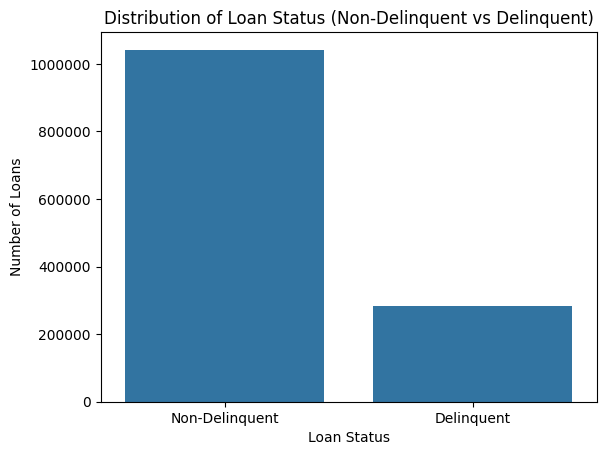

In [103]:
# Visualizing the distribution of the target variable (bad_status)
# to examine class imbalance between delinquent and non-delinquent loans
# 0 = Non-Delinquent
# 1 = Delinquent

import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='bad_status', data=df)

plt.title('Distribution of Loan Status (Non-Delinquent vs Delinquent)')
plt.xticks([0, 1], ['Non-Delinquent', 'Delinquent'])
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')
plt.ticklabel_format(style='plain', axis='y')
plt.show()


The count plot illustrates the distribution of the target variable bad_status, which classifies loans as `non-delinquent (0)` or `delinquent (1`). The dataset is noticeably imbalanced, with non-delinquent loans representing the majority of observations. Approximately 79% of loans fall into the non-delinquent category, while about 21% are classified as delinquent. This class imbalance is common in credit risk datasets and is important to consider during model development, as it may influence predictive performance and require techniques such as class weighting or resampling.



### Correlation Analysis

In [104]:
# Selecting key features for correlation analysis with the target variable (bad_status)

key_vars = [
    'bad_status',
    'loan_amnt',
    'int_rate',
    'installment',
    'annual_inc',
    'dti',
    'grade',
    'sub_grade',
    'grade_combined',
    'credit_history_years',
    'loan_age_years'
]

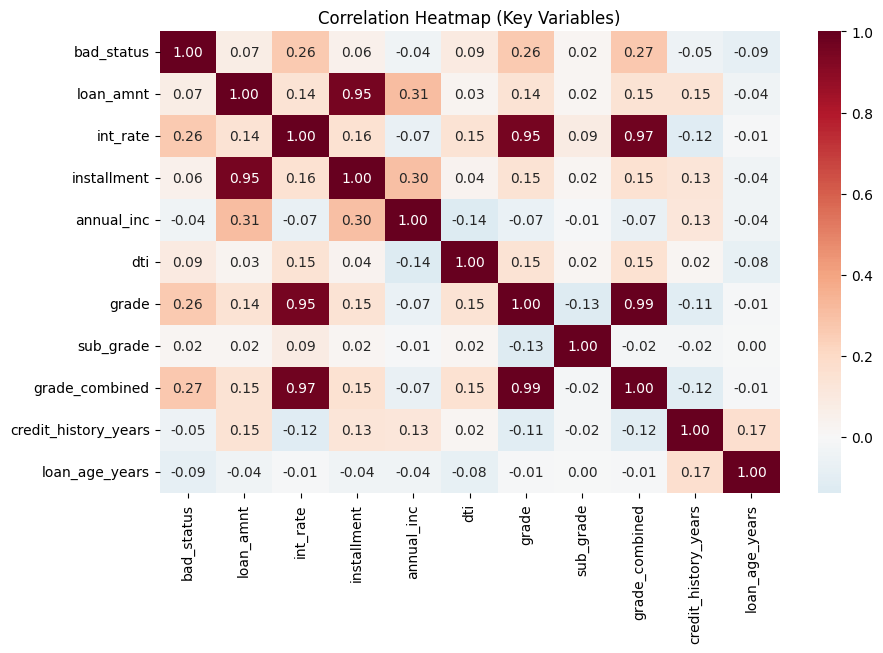

In [105]:
# Correlation heatmap of selected numerical variables
# used to examine relationships with the target variable

corr = df[key_vars].corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='RdBu_r',   # better contrast (red vs blue)
    center=0,        # makes 0 neutral (white-ish)
    fmt=".2f"
)

plt.title('Correlation Heatmap (Key Variables)')
plt.show()


The correlation heatmap highlights relationships between key numerical variables and the target variable, `bad_status`.
`Interest rate` and `grade_combined` variables exhibit the strongest positive relationships with delinquency, suggesting that higher-risk borrowers are more likely to fall behind on payments. Other variables, such as `annual income` and `debt-to-income ratio`, exhibit weaker correlations with the target.
Additionally, several predictor variables show extremely strong correlations with one another, particularly `loan amount` and `installment`, as well as `interest rate` and `grade`. These relationships suggest potential multicollinearity and feature redundancy, which may need to be addressed during model development.

### Interest Rate Analysis

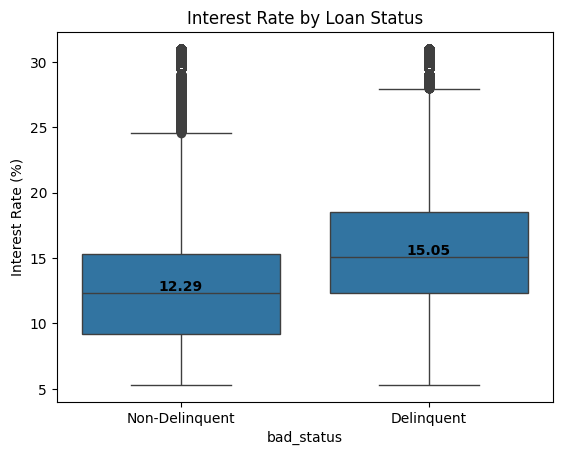

In [106]:
# Visualizing how interest rates differ between non-delinquent and delinquent loans
# This helps identify whether higher borrowing costs are associated 
# with a higher risk of falling behind on payments

# Create the boxplot
sns.boxplot(x='bad_status', y='int_rate', data=df)

# Calculate medians
medians = df.groupby('bad_status')['int_rate'].median()

# Add median values to the plot
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Delinquent', 'Delinquent'])
plt.ylabel('Interest Rate (%)')
plt.title('Interest Rate by Loan Status')

plt.show()

The boxplot shows that delinquent loans tend to have higher interest rates than non-delinquent loans. The median interest rate is clearly higher, and the overall distribution is shifted upward. This suggests that higher borrowing costs may be associated with an increased likelihood of falling behind on payments.

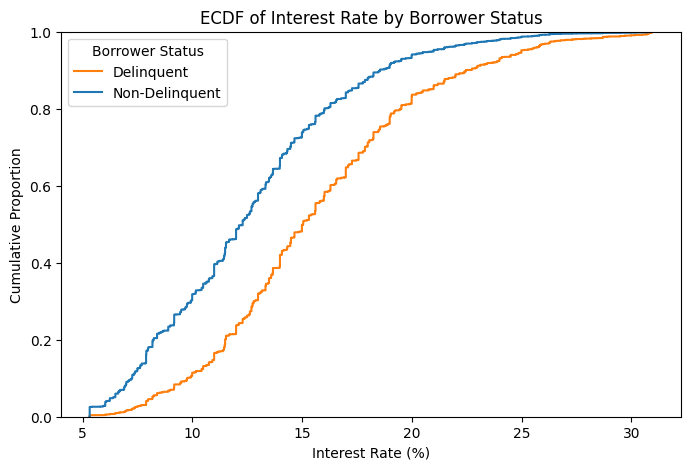

In [107]:
plt.figure(figsize=(8,5))

sns.ecdfplot(
    data=df,
    x='int_rate',
    hue='bad_status'
)

plt.xlabel('Interest Rate (%)')
plt.ylabel('Cumulative Proportion')
plt.title('ECDF of Interest Rate by Borrower Status')

# Custom legend labels
plt.legend(
    labels=['Delinquent', 'Non-Delinquent'],
    title='Borrower Status'
)

plt.show()

This ECDF plot compares the distribution of interest rates between delinquent and non-delinquent borrowers. The delinquent borrower distribution is shifted to the right, indicating that delinquent loans generally carry higher interest rates. In contrast, non-delinquent borrowers are more concentrated at lower interest rates. The visible separation between the two curves suggests that interest rate may be an important factor associated with borrower delinquency and supports the earlier findings from the boxplot analysis.

### Loan Grade (Combined) Analysis

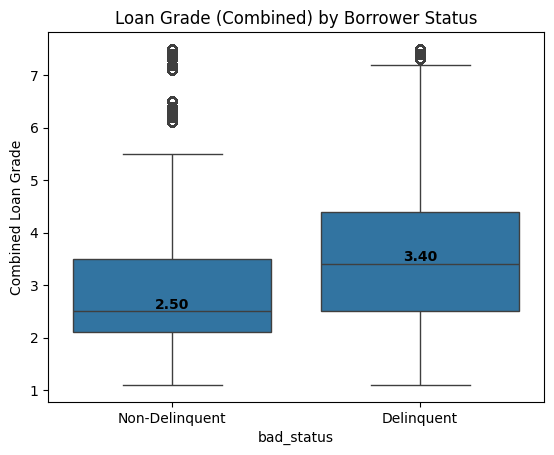

In [108]:
# Visualizing how loan grade (combined) differs between non-delinquent and delinquent loans
# This helps identify whether lower credit quality (higher grade values) is associated
# with a higher risk of falling behind on payments

# Create the boxplot
sns.boxplot(x='bad_status', y='grade_combined', data=df)

# Calculate medians
medians = df.groupby('bad_status')['grade_combined'].median()

# Step 3: Add median values to the plot
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Delinquent', 'Delinquent'])
plt.ylabel('Combined Loan Grade')
plt.title('Loan Grade (Combined) by Borrower Status')
plt.show()

This plot shows how the combined loan grade differs between non-delinquent and delinquent borrowers.

The median combined grade for delinquent loans (3.40 - C4) is higher than that of non-delinquent loans (2.50 - B5), indicating that borrowers with weaker credit profiles are more likely to fall behind on payments.

The overall distribution of grades for delinquent loans is shifted upward, suggesting that poorer loan grades are associated with higher delinquency risk.

However, there are also several high-grade (riskier) loans within the non-delinquent group, indicating that while loan grade is an important predictor, it does not fully determine borrower behavior. Some higher-risk borrowers are still able to meet their payment obligations.

### DTI (debt-to-income) Analysis

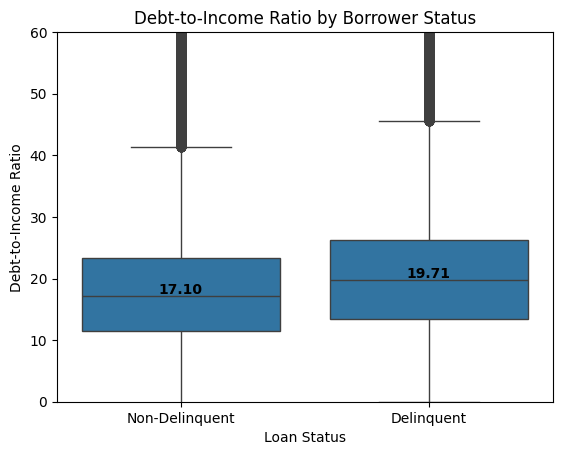

In [109]:
# Visualizing how DTI differs between non-delinquent and delinquent loans
# The y-axis is limited because extreme outliers make the boxplot hard to read

sns.boxplot(x='bad_status', y='dti', data=df)

# Calculate medians
medians = df.groupby('bad_status')['dti'].median()

# Add median values
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Delinquent', 'Delinquent'])
plt.ylabel('Debt-to-Income Ratio')
plt.xlabel('Loan Status')
plt.title('Debt-to-Income Ratio by Borrower Status')

# Limit y-axis to make the main distribution visible
plt.ylim(0, 60)

plt.show()

The box plot comparing debt-to-income (DTI) ratios shows that delinquent borrowers tend to have slightly higher DTI values compared to non-delinquent borrowers. The median DTI for delinquent loans is higher, indicating that borrowers with greater debt relative to their income may be more likely to fall behind on payments. However, the difference between the two groups is moderate, suggesting that DTI alone is not a strong predictor of delinquency. Extreme outliers are present in the data, and the y-axis was limited to better visualize the main distribution.

### Annual Income Analysis

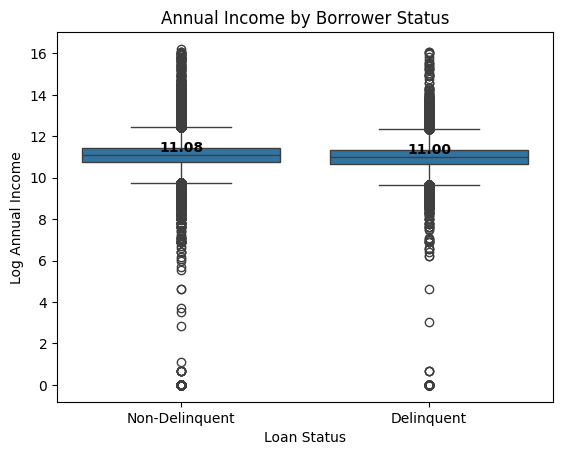

In [110]:
# Visualizing how annual income differs between non-delinquent and delinquent loans
# Annual income is highly skewed, so log income is used to make the distribution easier to compare

df['log_annual_inc'] = np.log1p(df['annual_inc'])

sns.boxplot(x='bad_status', y='log_annual_inc', data=df)

# Calculate medians
medians = df.groupby('bad_status')['log_annual_inc'].median()

# Add median values
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.2f}',
             ha='center', va='bottom',
             fontsize=10, fontweight='bold')

# Labels and title
plt.xticks([0, 1], ['Non-Delinquent', 'Delinquent'])
plt.ylabel('Log Annual Income')
plt.xlabel('Loan Status')
plt.title('Annual Income by Borrower Status')

plt.show()

The distribution of annual income appears very similar between delinquent and non-delinquent borrowers. The median values are nearly identical, and there is significant overlap between the two groups. This suggests that annual income does not have a strong direct relationship with delinquency in this dataset. Due to the presence of extreme values, a logarithmic transformation was applied to improve visualization, but even after transformation, the difference between groups remains minimal.  

Overall, interest rate and loan grade show stronger relationships with delinquency, while variables such as income and DTI provide weaker signals and may be more useful when combined with other features.

### Loan Purpose Distribution by Borrower Status

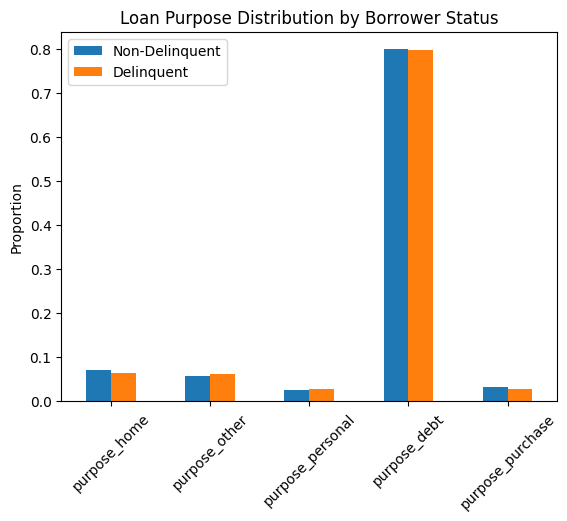

In [111]:
# Visualizing how loan purpose is associated with borrower delinquency
# Since loan purpose was one-hot encoded, we analyze the average proportion
# of each purpose category within delinquent and non-delinquent groups.
# This helps identify whether certain borrowing purposes are linked to higher risk.

purpose_cols = [
    'purpose_home',
    'purpose_other',
    'purpose_personal',
    'purpose_debt',
    'purpose_purchase'
]

# Calculate delinquency rate for each purpose
purpose_rates = df.groupby('bad_status')[purpose_cols].mean().T

# Plot
purpose_rates.plot(kind='bar')
plt.title('Loan Purpose Distribution by Borrower Status')
plt.ylabel('Proportion')
plt.xticks(rotation=45)
plt.legend(['Non-Delinquent', 'Delinquent'])
plt.show()

The distribution of loan purpose appears very similar between delinquent and non-delinquent borrowers. The majority of loans in both groups are associated with debt consolidation, and other categories show comparable proportions. This suggests that loan purpose does not have a strong relationship with delinquency in this dataset.